# Per-Antenna Beams and Eigenbeam Decomposition

In this notebook we demonstrate `fftvis`'s support for **per-antenna beams** and the associated **eigenbeam decomposition** that makes large heterogeneous-array simulations tractable.

By default, `fftvis` assumes a single beam is shared by every antenna. Many real-world arrays, however, exhibit antenna-to-antenna beam variation — for example through dish-size scatter, pointing offsets, or per-element gain patterns. `fftvis` supports this through two mechanisms:

1. **Per-antenna beams** — pass a list of beams (one per unique beam type) and a `beam_idx` array that maps each antenna to its beam.
2. **Eigenbeam decomposition** — factor the per-antenna beams into a small set of orthogonal basis beams (eigenbeams) plus per-antenna linear coefficients, then exploit the resulting structure to reduce the number of NUFFTs required.

<div class="alert alert-warning">

__Warning__

The eigenbeam decomposition is currently only supported for **polarized** simulations (`polarized=True`). Attempting to use `beam_coefs` with `polarized=False` will raise a `ValueError`.
</div>

In [1]:
# Standard imports
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from copy import deepcopy

# HERA-stack imports
import fftvis
import matvis
from hera_sim.antpos import hex_array
from hera_cal import redcal
from pyuvdata import GaussianBeam
from pyuvdata.telescopes import Telescope

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Simulation setup

We use the same sky model, array geometry, and time/frequency axes as the main `fftvis` tutorial. The key difference is that we now assign a **distinct beam to every antenna** by drawing dish diameters uniformly at random from the interval $[13, 15]$ metres — a toy model for realistic manufacturing scatter.

In [2]:
# Reproducible random state
rng = np.random.default_rng(42)

# Antenna positions — hex array of 19 antennas
antpos = hex_array(4, split_core=True, outriggers=0)
nants = len(antpos)

# Observation frequency and times
freq = 150e6                              # single frequency (Hz)
times = np.linspace(2459959, 2459959.5, 4)
telescope_loc = Telescope.from_known_telescopes("hera").location

# Sky model — HEALPix map of random point sources
nside = 64
npix = hp.nside2npix(nside)
dec, ra = hp.pix2ang(nside, np.arange(npix))
dec -= np.pi / 2
flux = np.abs(rng.standard_normal((npix, 1)))  # (nsrc, nfreq)

# Baselines — one representative per redundant group
reds = redcal.get_pos_reds(antpos, include_autos=True)
baselines = [red[0] for red in reds]

### Per-antenna beam list

We construct a `GaussianBeam` for every antenna, converting each to a tabulated `UVBeam` on a shared angular grid. We use the `GaussianBeam` here so that all beams share the same angular support, which is required for the eigenbeam decomposition to work correctly — the SVD is performed on the stacked data arrays, so the grid must be identical for every beam.

In [5]:
g = GaussianBeam(diameter=14.0)

In [8]:
# Reference beam — used to define the shared angular grid
ref_beam = GaussianBeam(diameter=14.0).to_uvbeam(
    freq_array=np.array([freq]),
    beam_type="efield",
    axis1_array=np.linspace(0, 2 * np.pi, 361),
    axis2_array=np.linspace(0, np.pi, 181),
)

# Per-antenna beams with randomised dish diameters
diameters = rng.uniform(13, 15, nants)
beam_list = [
    GaussianBeam(diameter=d).to_uvbeam(
        axis1_array=ref_beam.axis1_array,
        axis2_array=ref_beam.axis2_array,
        freq_array=np.array([freq]),
    )
    for d in diameters
]

print(f"Number of antennas: {nants}")
print(f"Dish diameters (m): min={diameters.min():.2f}, max={diameters.max():.2f}")

Number of antennas: 33
Dish diameters (m): min=13.16, max=14.99


## Method 1 — per-antenna beams (reference)

The simplest way to handle per-antenna variation is to pass a list of beams directly with `beam_idx` mapping each antenna to its entry. Internally, `fftvis` runs a separate NUFFT for every unique beam pair $(i, j)$, so the cost scales as $\mathcal{O}(N_\text{ant}^2)$ NUFFTs in the worst case.

In [9]:
%%time
vis_per_antenna = fftvis.simulate_vis(
    antpos,
    fluxes=flux,
    ra=ra,
    dec=dec,
    freqs=np.array([freq]),
    times=times,
    beam=beam_list,
    beam_idx=np.arange(nants),          # each antenna gets its own beam
    telescope_loc=telescope_loc,
    beam_spline_opts={"order": 1},
    coord_method_params={"update_bcrs_every": 1e9},
    baselines=baselines,
    interpolation_function="az_za_map_coordinates",
    polarized=True,
)

CPU times: user 5min 21s, sys: 32.5 s, total: 5min 53s
Wall time: 51.7 s


## Method 2 — eigenbeam decomposition

### Why decompose?

In the per-antenna path above, every distinct beam product $B_i(\hat{n}) B_j^*(\hat{n})$ requires its own NUFFT over the sky. For an array of $N_\text{ant}$ antennas with all-distinct beams this is $\mathcal{O}(N_\text{ant}^2)$ NUFFTs.

The eigenbeam approach exploits the fact that a set of similar beams (like our Gaussian beams with slightly different diameters) span a **low-dimensional subspace**. We decompose the beam matrix $\mathbf{B} \in \mathbb{R}^{N_\text{ant} \times N_\text{pix}}$ via a truncated SVD:

$$B_i(\hat{n}) \approx \sum_{k=1}^{K} c_{ik}\, e_k(\hat{n}), \qquad K \ll N_\text{ant}$$

where $\{e_k\}$ are the eigenbeams (right singular vectors) and $\{c_{ik}\}$ are the per-antenna coefficients (left singular vectors scaled by singular values). The visibility integral for baseline $(i,j)$ then becomes

$$V_{ij} = \sum_{k,l} c_{ik}\, c_{jl}^* \underbrace{\int e_k(\hat{n})\, e_l^*(\hat{n})\, I(\hat{n})\, e^{2\pi i \mathbf{b}_{ij} \cdot \hat{n}}\, d\hat{n}}_{\mathcal{T}_{kl}(\mathbf{b}_{ij})}$$

The $K^2$ transfer integrals $\mathcal{T}_{kl}$ are computed once (one NUFFT each, evaluated at all baseline vectors simultaneously), and every $V_{ij}$ is then assembled by a cheap bilinear combination — $K^2$ multiplications and additions per baseline.

### Step 1 — compute the eigenbeam basis

`fftvis.compute_beam_basis` performs the SVD and returns:

- `eigenbeams` — a list of $K$ `UVBeam` objects, one per retained mode
- `coeffs` — a `(N_\text{ant}, K)` array of per-antenna coefficients

The `threshold` parameter controls how many modes are retained: modes whose singular value is smaller than `threshold` times the largest singular value are discarded. A smaller threshold retains more modes and gives a more accurate (but more expensive) decomposition.

In [10]:
%%time
eigenbeams, coeffs = fftvis.compute_beam_basis(
    deepcopy(beam_list),   # copies are used because beam data may be modified in-place
    freq,
    threshold=1e-12,       # retain essentially all numerical rank
    polarized=True,
)

print(f"Number of antennas:  {nants}")
print(f"Number of eigenbeams: {len(eigenbeams)}")
print(f"Coefficient array shape: {coeffs.shape}")

Number of antennas:  33
Number of eigenbeams: 8
Coefficient array shape: (33, 8)
CPU times: user 15.8 s, sys: 1.1 s, total: 16.9 s
Wall time: 16.3 s


Even though all dish diameters are distinct, the Gaussian beams with diameters drawn from $[13, 15]$ m are very similar to one another. The SVD therefore finds that the beams lie near a very low-dimensional subspace, and most singular values drop off rapidly after the first few modes.

### Singular value spectrum

To understand how many modes are actually meaningful, it is useful to inspect the singular value spectrum directly. We recompute it here from the stacked beam data arrays (the same matrix `compute_beam_basis` decomposes internally).

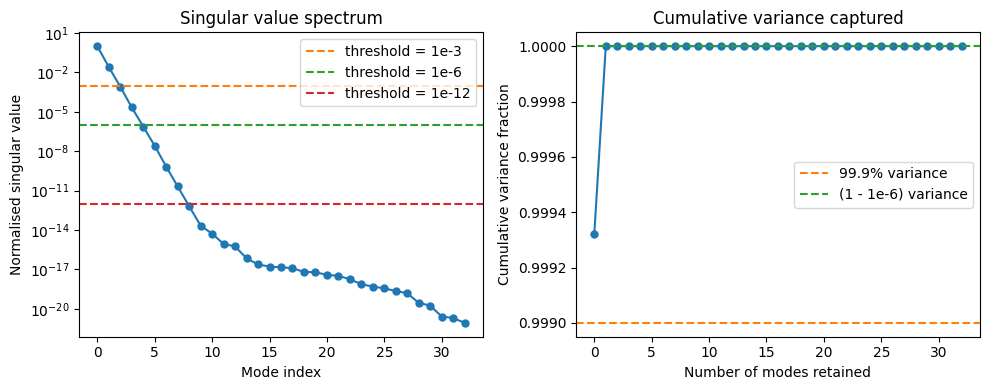

In [11]:
# Stack the efield beam data into a (nant, npix_flat) matrix
# We take a single polarization and frequency slice for illustration.
beam_matrix = np.stack(
    [b.data_array[0, 0, 0].ravel() for b in beam_list],
    axis=0,
)  # shape (nant, npix_flat), complex

singular_values = np.linalg.svd(np.abs(beam_matrix), compute_uv=False)
singular_values_normalised = singular_values / singular_values[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].semilogy(singular_values_normalised, "o-", ms=5)
axes[0].axhline(1e-3, color="C1", ls="--", label="threshold = 1e-3")
axes[0].axhline(1e-6, color="C2", ls="--", label="threshold = 1e-6")
axes[0].axhline(1e-12, color="C3", ls="--", label="threshold = 1e-12")
axes[0].set_xlabel("Mode index")
axes[0].set_ylabel("Normalised singular value")
axes[0].set_title("Singular value spectrum")
axes[0].legend()

# Cumulative fraction of variance captured
cumvar = np.cumsum(singular_values**2) / np.sum(singular_values**2)
axes[1].plot(cumvar, "o-", ms=5)
axes[1].axhline(0.999, color="C1", ls="--", label="99.9% variance")
axes[1].axhline(1.0 - 1e-6, color="C2", ls="--", label="(1 - 1e-6) variance")
axes[1].set_xlabel("Number of modes retained")
axes[1].set_ylabel("Cumulative variance fraction")
axes[1].set_title("Cumulative variance captured")
axes[1].legend()

plt.tight_layout()
plt.show()

<div class="alert alert-info">

__Choosing a threshold__

The plot above illustrates the tradeoff: a looser `threshold` (e.g. `1e-3`) retains fewer eigenbeams ($K$ is smaller) and therefore requires fewer NUFFTs, but introduces a larger approximation error into the beam product. A tight threshold (e.g. `1e-12`) retains nearly the full numerical rank and makes the eigenbeam path essentially exact, at the cost of more NUFFTs. For nearly-homogeneous arrays the singular value spectrum typically drops steeply after the first one or two modes, so even a tight threshold gives a very small $K$.
</div>

### Step 2 — run the eigenbeam simulation

The eigenbeam simulation is invoked identically to the standard `simulate_vis` call, but instead of `beam_idx` you pass `beam_coefs`. The `beam_coefs` array has shape `(N_\text{ant}, K, N_\text{freq})` — the extra frequency axis allows the coefficients to vary with frequency when multi-frequency beams are used. For a single frequency, we simply add a trailing size-1 axis.

In [12]:
%%time
vis_eigenbeam = fftvis.simulate_vis(
    antpos,
    fluxes=flux,
    ra=ra,
    dec=dec,
    freqs=eigenbeams[0].freq_array[:1],
    times=times,
    beam=eigenbeams,
    beam_coefs=coeffs[..., None],       # (nant, K) → (nant, K, nfreq=1)
    telescope_loc=telescope_loc,
    beam_spline_opts={"order": 1},
    coord_method_params={"update_bcrs_every": 1e9},
    baselines=baselines,
    interpolation_function="az_za_map_coordinates",
    polarized=True,
)

CPU times: user 26.7 s, sys: 3.16 s, total: 29.9 s
Wall time: 3.47 s


## Verification

We verify both paths against `matvis`, which uses a direct beam-product computation and serves as the reference implementation.

In [14]:
from astropy.time import Time

In [15]:
%%time
vis_matvis = matvis.simulate_vis(
    antpos,
    fluxes=flux,
    ra=ra,
    dec=dec,
    freqs=np.array([freq]),
    times=Time(times, format="jd"),
    beams=beam_list,
    telescope_loc=telescope_loc,
    beam_spline_opts={"order": 1},
    coord_method_params={"update_bcrs_every": 1e9},
    coord_method="CoordinateRotationERFA",
    antpairs=np.array(baselines),
    precision=2,
    polarized=True,
)

CPU times: user 7.37 s, sys: 708 ms, total: 8.08 s
Wall time: 6.21 s


In [16]:
# Compare per-antenna path vs matvis
diff_pa = vis_per_antenna[..., 1, 1, :] - vis_matvis[..., 1, 1]
print("per-antenna vs matvis:")
print(f"  mean |Δre| = {np.abs(np.real(diff_pa)).mean():.3e}")
print(f"  mean |Δim| = {np.abs(np.imag(diff_pa)).mean():.3e}")

# Compare eigenbeam path vs matvis
diff_eb = vis_eigenbeam[..., 1, 1, :] - vis_matvis[..., 1, 1]
print("\neigenbeam vs matvis:")
print(f"  mean |Δre| = {np.abs(np.real(diff_eb)).mean():.3e}")
print(f"  mean |Δim| = {np.abs(np.imag(diff_eb)).mean():.3e}")

# Compare the two fftvis paths against each other
diff_both = vis_eigenbeam[..., 1, 1, :] - vis_per_antenna[..., 1, 1, :]
print("\neigenbeam vs per-antenna (fftvis internal):")
print(f"  mean |Δre| = {np.abs(np.real(diff_both)).mean():.3e}")
print(f"  mean |Δim| = {np.abs(np.imag(diff_both)).mean():.3e}")

per-antenna vs matvis:
  mean |Δre| = 1.572e-13
  mean |Δim| = 1.611e-13

eigenbeam vs matvis:
  mean |Δre| = 6.583e-13
  mean |Δim| = 4.185e-13

eigenbeam vs per-antenna (fftvis internal):
  mean |Δre| = 6.055e-13
  mean |Δim| = 3.619e-13


All three comparisons should agree at the level of floating-point rounding ($\lesssim 10^{-12}$ relative to a typical visibility amplitude), since at `threshold=1e-12` the eigenbeam decomposition retains the full numerical rank and introduces no truncation error beyond the NUFFT tolerance.

## Effect of truncation threshold

To illustrate the accuracy-vs-speed tradeoff, we repeat the eigenbeam simulation at several threshold values and measure the residual against the per-antenna reference.

In [17]:
thresholds = [1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-12]
n_modes = []
mean_errors = []

for thr in thresholds:
    ebs, cfs = fftvis.compute_beam_basis(
        deepcopy(beam_list), freq, threshold=thr, polarized=True
    )
    vis_thr = fftvis.simulate_vis(
        antpos,
        fluxes=flux,
        ra=ra,
        dec=dec,
        freqs=ebs[0].freq_array[:1],
        times=times,
        beam=ebs,
        beam_coefs=cfs[..., None],
        telescope_loc=telescope_loc,
        beam_spline_opts={"order": 1},
        coord_method_params={"update_bcrs_every": 1e9},
        baselines=baselines,
        interpolation_function="az_za_map_coordinates",
        polarized=True,
    )
    diff = vis_thr[..., 1, 1, :] - vis_per_antenna[..., 1, 1, :]
    rel_err = np.abs(diff).mean() / np.abs(vis_per_antenna[..., 1, 1, :]).mean()
    n_modes.append(len(ebs))
    mean_errors.append(float(rel_err))
    print(f"threshold={thr:.0e}  K={len(ebs):3d}  mean relative error={rel_err:.2e}")

threshold=1e-02  K=  2  mean relative error=4.98e-04
threshold=1e-03  K=  2  mean relative error=4.98e-04
threshold=1e-04  K=  3  mean relative error=1.47e-05
threshold=1e-06  K=  4  mean relative error=5.61e-07
threshold=1e-08  K=  6  mean relative error=3.64e-10
threshold=1e-12  K=  8  mean relative error=3.69e-13


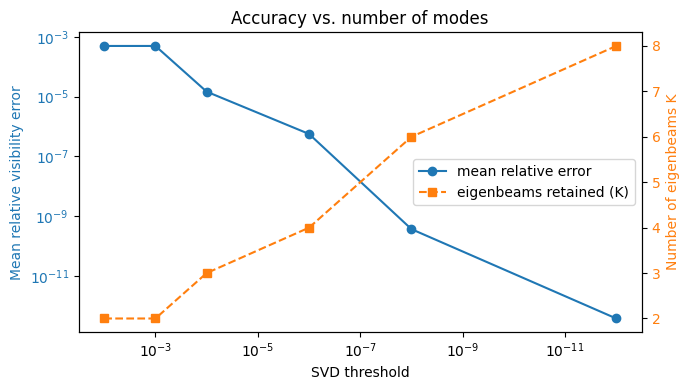

In [18]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.semilogy(thresholds, mean_errors, "o-C0", ms=6, label="mean relative error")
ax2.plot(thresholds, n_modes, "s--C1", ms=6, label="eigenbeams retained (K)")

ax1.set_xscale("log")
ax1.invert_xaxis()
ax1.set_xlabel("SVD threshold")
ax1.set_ylabel("Mean relative visibility error", color="C0")
ax2.set_ylabel("Number of eigenbeams K", color="C1")
ax1.tick_params(axis="y", labelcolor="C0")
ax2.tick_params(axis="y", labelcolor="C1")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax1.set_title("Accuracy vs. number of modes")
plt.tight_layout()
plt.show()

The plot illustrates the key tradeoff: tightening the threshold retains more modes and drives the approximation error down, but at the cost of more NUFFTs (proportional to $K^2$). For nearly-homogeneous arrays a single eigenbeam often captures $>99.9\%$ of the variance, so an aggressive threshold can give order-of-magnitude speedups with negligible loss in accuracy.